# Projekt 3: Klasyfikacja wieloklasowa obrazów liści (PlantVillage)

Zadania:
1. Funkcja `gen_train_test` — podział danych na katalogi train/test
2. Funkcje `load_train_images` / `load_test_images` — wczytywanie i przygotowanie danych
3. Przygotowanie `data_src` z 10 klasami z PlantVillage
4. Klasyfikacja z `LogisticRegression` (OVR i multinomial)
5. Macierze pomyłek, accuracy, recall, precision, F1

In [1]:
import os
import shutil
import csv
import json
import random
import numpy as np
import cv2 as cv
from skimage import io as skio
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt

%matplotlib inline

print('Importy załadowane.')

Importy załadowane.


## 1. Funkcja `gen_train_test`

Generuje katalog `data/` z podkatalogami `train/` i `test/` oraz plik `test_labels.csv`.

In [2]:
def gen_train_test(container_dir, max_category_sample=500, test_ratio=0.2, seed=42):
    data_dir = 'data'
    train_dir = os.path.join(data_dir, 'train')
    test_dir = os.path.join(data_dir, 'test')
    labels_path = os.path.join(data_dir, 'test_labels.csv')
    
    if os.path.exists(data_dir):
        shutil.rmtree(data_dir)
    
    os.makedirs(train_dir)
    os.makedirs(test_dir)
    
    random.seed(seed)
    test_labels = []
    
    categories = sorted([
        d for d in os.listdir(container_dir)
        if os.path.isdir(os.path.join(container_dir, d))
    ])
    
    for category in categories:
        cat_path = os.path.join(container_dir, category)
        files = [
            f for f in os.listdir(cat_path)
            if os.path.isfile(os.path.join(cat_path, f))
        ]
        random.shuffle(files)
        
        total_available = len(files)
        n_train = min(max_category_sample, int(total_available * (1 - test_ratio)))
        n_test = min(total_available - n_train, max(1, int(n_train * test_ratio / (1 - test_ratio))))
        
        train_files = files[:n_train]
        test_files = files[n_train:n_train + n_test]
        
        cat_train_dir = os.path.join(train_dir, category)
        os.makedirs(cat_train_dir)
        for f in train_files:
            shutil.copy2(os.path.join(cat_path, f), os.path.join(cat_train_dir, f))
        
        for f in test_files:
            test_fname = f'{category}__{f}'
            shutil.copy2(os.path.join(cat_path, f), os.path.join(test_dir, test_fname))
            test_labels.append((test_fname, category))
        
        print(f'  {category}: train={len(train_files)}, test={len(test_files)}')
    
    with open(labels_path, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(['filename', 'label'])
        writer.writerows(test_labels)
    
    print(f'\nKatalog data utworzony.')
    print(f'  Train: {train_dir} ({len(categories)} klas)')
    print(f'  Test: {test_dir} ({len(test_labels)} plików)')
    print(f'  Etykiety: {labels_path}')
    
    return data_dir

print('Funkcja gen_train_test zdefiniowana.')

Funkcja gen_train_test zdefiniowana.


## 2. Funkcja `load_train_images`

Wczytuje obrazy treningowe z `data/train`, zmienia rozmiar, normalizuje/standaryzuje i spłaszcza.

In [3]:
def _process_image(fpath, newSize, interpol, colorConv, ignore_image_a):
    img = skio.imread(fpath)
    
    if ignore_image_a and img.ndim == 3 and img.shape[2] == 4:
        img = img[:, :, :3]
    
    if colorConv is not None:
        img = cv.cvtColor(img, colorConv)
    
    img = cv.resize(img, newSize, interpolation=interpol)
    
    return img.flatten().astype(np.float64)


def load_train_images(container_path, newSize=(64, 64), interpol=cv.INTER_AREA,
                      colorConv=None, stand=False, ignore_image_a=True,
                      norm=True, max_sample=200):
    categories = sorted([
        d for d in os.listdir(container_path)
        if os.path.isdir(os.path.join(container_path, d))
    ])
    
    train_img = []
    labels = []
    
    for cat in categories:
        cat_path = os.path.join(container_path, cat)
        files = sorted([
            f for f in os.listdir(cat_path)
            if os.path.isfile(os.path.join(cat_path, f))
        ])[:max_sample]
        
        for fname in files:
            fpath = os.path.join(cat_path, fname)
            try:
                img_flat = _process_image(fpath, newSize, interpol, colorConv, ignore_image_a)
                train_img.append(img_flat)
                labels.append(cat)
            except Exception as e:
                continue
        
        print(f'  {cat}: {sum(1 for l in labels if l == cat)} obrazów')
    
    data = np.array(train_img)
    
    if norm and not stand:
        data = data / 255.0
    elif stand:
        mean = data.mean(axis=0)
        std = data.std(axis=0) + 1e-8
        data = (data - mean) / std
    
    X = {
        'data': data,
        'categories_name': categories,
        'categories_count': len(categories),
        'labels': labels,
    }
    
    print(f'\nŁącznie: {len(labels)} obrazów, {len(categories)} klas')
    print(f'Wymiar danych: {data.shape}')
    return X

print('Funkcja load_train_images zdefiniowana.')

Funkcja load_train_images zdefiniowana.


## 3. Funkcja `load_test_images`

Wczytuje dane testowe z `data/test` korzystając z `test_labels.csv`.

In [4]:
def load_test_images(container_path, newSize=(64, 64), interpol=cv.INTER_AREA,
                     colorConv=None, stand=False, ignore_image_a=True,
                     norm=True, max_sample=200):
    labels_path = os.path.join(os.path.dirname(container_path), 'test_labels.csv')
    file_labels = {}
    with open(labels_path, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            file_labels[row['filename']] = row['label']
    
    categories = sorted(set(file_labels.values()))
    files_by_cat = {cat: [] for cat in categories}
    for fname, label in file_labels.items():
        files_by_cat[label].append(fname)
    
    per_class = max_sample // len(categories)
    
    test_img = []
    labels = []
    
    for cat in categories:
        cat_files = sorted(files_by_cat[cat])[:per_class]
        for fname in cat_files:
            fpath = os.path.join(container_path, fname)
            if not os.path.isfile(fpath):
                continue
            try:
                img_flat = _process_image(fpath, newSize, interpol, colorConv, ignore_image_a)
                test_img.append(img_flat)
                labels.append(cat)
            except Exception:
                continue
        print(f'  {cat}: {sum(1 for l in labels if l == cat)} obrazów')
    
    data = np.array(test_img)
    
    if norm and not stand:
        data = data / 255.0
    elif stand:
        mean = data.mean(axis=0)
        std = data.std(axis=0) + 1e-8
        data = (data - mean) / std
    
    X = {
        'data': data,
        'categories_name': categories,
        'categories_count': len(categories),
        'labels': labels,
    }
    
    print(f'\nŁącznie: {len(labels)} obrazów testowych, {len(categories)} klas')
    print(f'Wymiar danych: {data.shape}')
    return X

print('Funkcja load_test_images zdefiniowana.')

Funkcja load_test_images zdefiniowana.


## 4. Przygotowanie `data_src` z 10 klasami z PlantVillage

Wybrane klasy (10):
- Apple___Apple_scab, Apple___Black_rot, Apple___healthy
- Corn_(maize)___Common_rust_, Corn_(maize)___healthy
- Grape___Black_rot, Grape___healthy
- Pepper,_bell___Bacterial_spot, Pepper,_bell___healthy
- Tomato___healthy

In [5]:
PLANTVILLAGE_DIR = os.path.join('..', 'l2', 'plantvillage', 'color')
DATA_SRC = 'data_src'

# 10 wybranych klas
SELECTED_CLASSES = [
    'Apple___Apple_scab',
    'Apple___Black_rot',
    'Apple___healthy',
    'Corn_(maize)___Common_rust_',
    'Corn_(maize)___healthy',
    'Grape___Black_rot',
    'Grape___healthy',
    'Pepper,_bell___Bacterial_spot',
    'Pepper,_bell___healthy',
    'Tomato___healthy',
]

if not os.path.exists(DATA_SRC):
    os.makedirs(DATA_SRC)
    for cls in SELECTED_CLASSES:
        src = os.path.join(PLANTVILLAGE_DIR, cls)
        dst = os.path.join(DATA_SRC, cls)
        if os.path.isdir(src):
            os.symlink(os.path.abspath(src), dst)
            n_files = len(os.listdir(dst))
            print(f'  {cls}: {n_files} obrazów (symlink)')
        else:
            print(f'  BRAK: {src}')
else:
    print(f'Katalog {DATA_SRC} już istnieje.')
    for cls in SELECTED_CLASSES:
        path = os.path.join(DATA_SRC, cls)
        if os.path.isdir(path):
            print(f'  {cls}: {len(os.listdir(path))} obrazów')
        else:
            print(f'  BRAK: {path}')

  Apple___Apple_scab: 630 obrazów (symlink)
  Apple___Black_rot: 621 obrazów (symlink)
  Apple___healthy: 1645 obrazów (symlink)
  Corn_(maize)___Common_rust_: 1192 obrazów (symlink)
  Corn_(maize)___healthy: 1162 obrazów (symlink)
  Grape___Black_rot: 1180 obrazów (symlink)
  Grape___healthy: 423 obrazów (symlink)
  Pepper,_bell___Bacterial_spot: 997 obrazów (symlink)
  Pepper,_bell___healthy: 1478 obrazów (symlink)
  Tomato___healthy: 1591 obrazów (symlink)


## 5. Generowanie katalogów train/test

In [6]:
# Wygeneruj podział train/test (max 500 treningowych na klasę)
gen_train_test(DATA_SRC, max_category_sample=500, test_ratio=0.2)

  Apple___Apple_scab: train=500, test=125
  Apple___Black_rot: train=496, test=124
  Apple___healthy: train=500, test=125
  Corn_(maize)___Common_rust_: train=500, test=125
  Corn_(maize)___healthy: train=500, test=125
  Grape___Black_rot: train=500, test=125
  Grape___healthy: train=338, test=84
  Pepper,_bell___Bacterial_spot: train=500, test=125
  Pepper,_bell___healthy: train=500, test=125
  Tomato___healthy: train=500, test=125

Katalog data utworzony.
  Train: data/train (10 klas)
  Test: data/test (1208 plików)
  Etykiety: data/test_labels.csv


'data'

## 6. Wczytanie danych i kodowanie etykiet

Obrazy 128×128, normalizacja [0,1], `LabelEncoder` do kodowania klas.

In [7]:
IMG_SIZE = (128, 128)  # 256x256 lub 128x128 przy problemach wydajnościowych

print('Wczytywanie danych treningowych...')
X_train_dict = load_train_images(
    'data/train', newSize=IMG_SIZE, interpol=cv.INTER_AREA,
    colorConv=None, stand=False, ignore_image_a=True, norm=True,
    max_sample=200
)

print('\nWczytywanie danych testowych...')
X_test_dict = load_test_images(
    'data/test', newSize=IMG_SIZE, interpol=cv.INTER_AREA,
    colorConv=None, stand=False, ignore_image_a=True, norm=True,
    max_sample=500
)

Wczytywanie danych treningowych...
  Apple___Apple_scab: 200 obrazów
  Apple___Black_rot: 200 obrazów
  Apple___healthy: 200 obrazów
  Corn_(maize)___Common_rust_: 200 obrazów
  Corn_(maize)___healthy: 200 obrazów
  Grape___Black_rot: 200 obrazów
  Grape___healthy: 200 obrazów
  Pepper,_bell___Bacterial_spot: 200 obrazów
  Pepper,_bell___healthy: 200 obrazów
  Tomato___healthy: 200 obrazów

Łącznie: 2000 obrazów, 10 klas
Wymiar danych: (2000, 49152)

Wczytywanie danych testowych...
  Apple___Apple_scab: 50 obrazów
  Apple___Black_rot: 50 obrazów
  Apple___healthy: 50 obrazów
  Corn_(maize)___Common_rust_: 50 obrazów
  Corn_(maize)___healthy: 50 obrazów
  Grape___Black_rot: 50 obrazów
  Grape___healthy: 50 obrazów
  Pepper,_bell___Bacterial_spot: 50 obrazów
  Pepper,_bell___healthy: 50 obrazów
  Tomato___healthy: 50 obrazów

Łącznie: 500 obrazów testowych, 10 klas
Wymiar danych: (500, 49152)


In [8]:
# Kodowanie etykiet za pomocą LabelEncoder
le = LabelEncoder()
le.fit(X_train_dict['categories_name'])

y_train = le.transform(X_train_dict['labels'])
y_test = le.transform(X_test_dict['labels'])

X_train = X_train_dict['data']
X_test = X_test_dict['data']

print(f'Klasy: {list(le.classes_)}')
print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape},  y_test:  {y_test.shape}')

Klasy: [np.str_('Apple___Apple_scab'), np.str_('Apple___Black_rot'), np.str_('Apple___healthy'), np.str_('Corn_(maize)___Common_rust_'), np.str_('Corn_(maize)___healthy'), np.str_('Grape___Black_rot'), np.str_('Grape___healthy'), np.str_('Pepper,_bell___Bacterial_spot'), np.str_('Pepper,_bell___healthy'), np.str_('Tomato___healthy')]
X_train: (2000, 49152), y_train: (2000,)
X_test:  (500, 49152),  y_test:  (500,)


## 7. Podgląd przykładowych obrazów

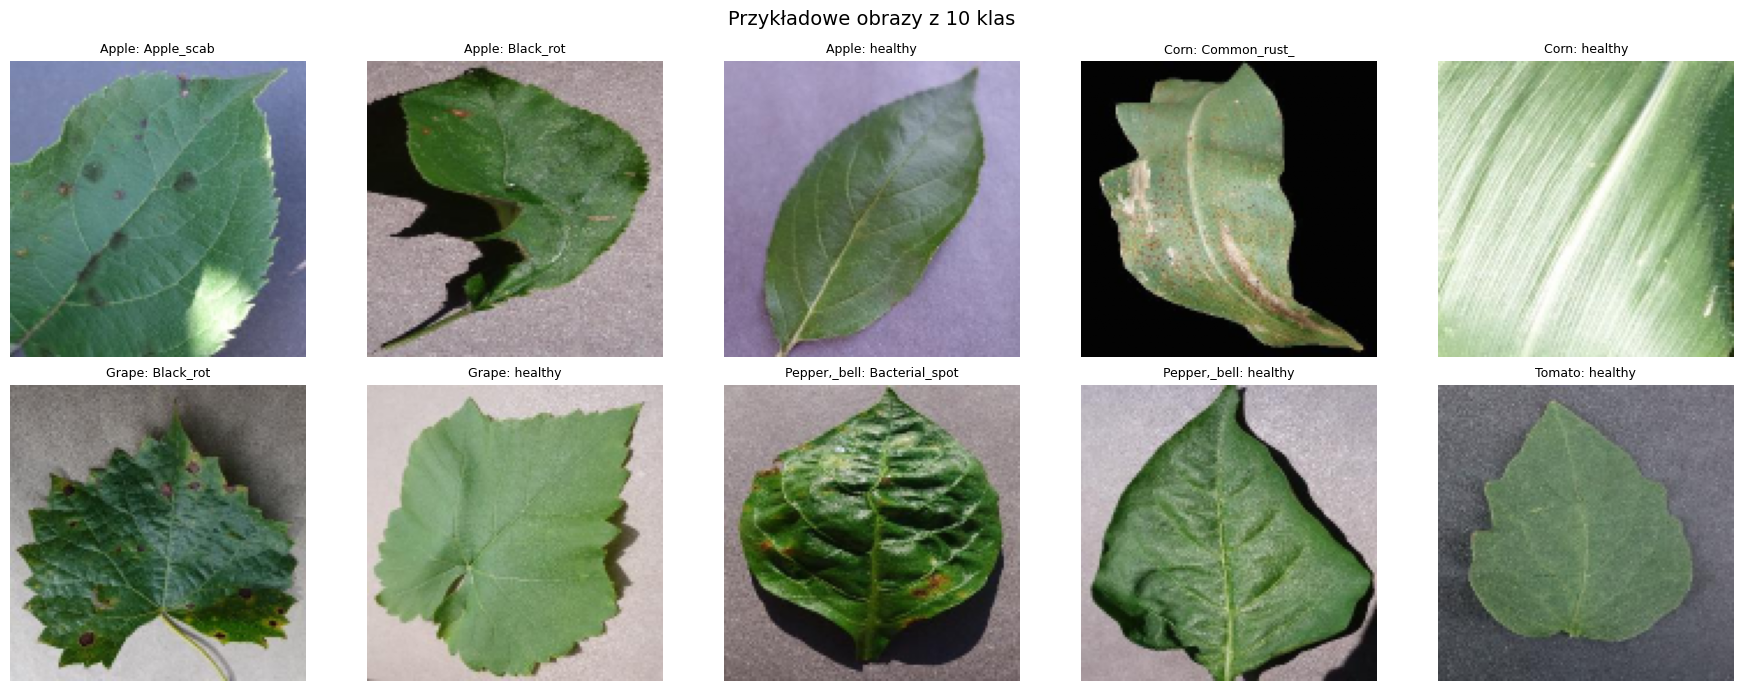

In [9]:
# Podgląd po jednym obrazie z każdej klasy
n_classes = X_train_dict['categories_count']
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

channels = IMG_SIZE[0] * IMG_SIZE[1] * 3

for i, cat in enumerate(le.classes_):
    idx = np.where(y_train == i)[0][0]
    img = X_train[idx].reshape(IMG_SIZE[1], IMG_SIZE[0], 3)
    axes[i].imshow(img)
    # Krótsza nazwa klasy
    short = cat.replace('___', ': ').replace('_(maize)', '')
    axes[i].set_title(short, fontsize=9)
    axes[i].axis('off')

plt.suptitle('Przykładowe obrazy z 10 klas', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Klasyfikacja: LogisticRegression

Dwie koncepcje algorytmu klasyfikacji wieloklasowej:
- **OVR** (One-vs-Rest): osobny klasyfikator binarny dla każdej klasy
- **Multinomial**: wspólna optymalizacja wieloklasowa (softmax)

In [ ]:
from sklearn.multiclass import OneVsRestClassifier

results = {}

strategies = {
    'ovr': OneVsRestClassifier(
        LogisticRegression(solver='lbfgs', max_iter=1000, C=1.0, random_state=42)
    ),
    'multinomial': LogisticRegression(
        solver='lbfgs', max_iter=1000, C=1.0, random_state=42
    ),
}

for strategy, model in strategies.items():
    print(f'\n{"="*60}')
    print(f'Strategia: {strategy}')
    print(f'{"="*60}')
    
    print('Trenowanie modelu...')
    model.fit(X_train, y_train)
    
    print('Predykcja na zbiorze testowym...')
    y_pred = model.predict(X_test)
    
    # Metryki
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f'\nWyniki ({strategy}):')
    print(f'  Accuracy:  {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1:        {f1:.4f}')
    
    results[strategy] = {
        'model': model,
        'y_pred': y_pred,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'cm': cm,
    }


multi_class = ovr


TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

## 9. Raporty klasyfikacji i macierze pomyłek

In [ ]:
# Szczegółowe raporty klasyfikacji
short_names = [c.replace('___', ': ').replace('_(maize)', '') for c in le.classes_]

for strategy, res in results.items():
    print(f'\n{"="*60}')
    print(f'RAPORT: multi_class = {strategy}')
    print(f'{"="*60}')
    print(classification_report(y_test, res['y_pred'],
                                target_names=short_names, zero_division=0))

In [ ]:
# Wizualizacja macierzy pomyłek
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, (strategy, res) in zip(axes, results.items()):
    cm = res['cm']
    im = ax.imshow(cm, cmap='Blues', interpolation='nearest')
    ax.set_title(f'Confusion Matrix: {strategy}', fontsize=13)
    
    tick_pos = np.arange(len(le.classes_))
    ax.set_xticks(tick_pos)
    ax.set_yticks(tick_pos)
    ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(short_names, fontsize=8)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    
    # Wartości liczbowe w komórkach
    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    fontsize=7, color='white' if cm[i, j] > thresh else 'black')
    
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## 10. Porównanie metryk OVR vs Multinomial

In [ ]:
# Porównanie metryk między OVR a Multinomial
metrics_names = ['accuracy', 'precision', 'recall', 'f1']
strategies = list(results.keys())

x_pos = np.arange(len(metrics_names))
width = 0.3

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2196F3', '#FF9800']

for i, strategy in enumerate(strategies):
    vals = [results[strategy][m] for m in metrics_names]
    bars = ax.bar(x_pos + i * width, vals, width, label=strategy.upper(), color=colors[i])
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Wartość metryki')
ax.set_title('Porównanie: OVR vs Multinomial')
ax.set_xticks(x_pos + width / 2)
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1'])
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 11. Podsumowanie

In [ ]:
# Tabela podsumowująca
print(f'{"Strategia":<15} | {"Accuracy":>8} | {"Precision":>9} | {"Recall":>6} | {"F1":>6}')
print('-' * 55)

for strategy, res in results.items():
    print(f'{strategy.upper():<15} | {res["accuracy"]:>8.4f} | {res["precision"]:>9.4f} | {res["recall"]:>6.4f} | {res["f1"]:>6.4f}')

print('-' * 55)
print(f'\nRozmiar obrazu: {IMG_SIZE}')
print(f'Liczba klas: {len(le.classes_)}')
print(f'Dane treningowe: {X_train.shape[0]} obrazów')
print(f'Dane testowe: {X_test.shape[0]} obrazów')
print(f'Wymiar cech: {X_train.shape[1]}')